# V-Beam Thermal Sensor - Physics-Informed NN Forward Model: Grid Search + Training

**What this notebook does:**
1. Computes analytical beam-mechanics predictions as soft physics constraints
2. Grid-searches PINN hyperparameters (60 combinations, fixed λ_physics = 0.1)
3. Re-trains the best configuration at full budget
4. Evaluates on the held-out test set
5. Saves the model + scalers to `../Models/`

**Training loss:**  `total = MSE(pred, y_FEA) + 0.1 × MSE(pred, y_analytical)`  
> Run `gradient-descent.ipynb` for inverse design.

## 1. Imports

In [22]:
import pandas as pd
import numpy as np
import itertools
import time
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import copy

torch.manual_seed(42)
np.random.seed(42)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU not found. Install CUDA-enabled PyTorch: "
        "https://pytorch.org/get-started/locally/"
    )
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB


## 2. Load Data

In [23]:
EXCEL_PATH = "../Data/Datasets/Dataset_complet_5.11.2025.xlsx"

df = pd.read_excel(EXCEL_PATH)
print(f"Dataset shape: {df.shape}")

INPUT_COLS  = ["Beta Angle", "Beam Length", "Beam Width",
               "Delta Temp", "Young's Modulus - E", "CTE - alpha"]
OUTPUT_COLS = ["Sensor Displacement", "Max Mechanical Stress", "Vol"]

df_clean = df[INPUT_COLS + OUTPUT_COLS].dropna()
print(f"Clean rows: {len(df_clean)}")
print()
print(df_clean.describe())

Dataset shape: (3000, 30)
Clean rows: 3000

        Beta Angle  Beam Length   Beam Width   Delta Temp  \
count  3000.000000  3000.000000  3000.000000  3000.000000   
mean     24.993200    27.510467     1.499800    45.292500   
std       8.670222     4.281793     0.295583    14.446169   
min      10.000000    20.000000     1.000000    20.000000   
25%      17.600000    23.800000     1.200000    32.800000   
50%      24.850000    27.600000     1.500000    45.100000   
75%      32.500000    31.200000     1.800000    57.900000   
max      40.000000    35.000000     2.000000    70.000000   

       Young's Modulus - E   CTE - alpha  Sensor Displacement  \
count               3000.0  3.000000e+03          3000.000000   
mean               71000.0  2.300000e-05             0.090790   
std                    0.0  3.388697e-21             0.042193   
min                71000.0  2.300000e-05             0.024984   
25%                71000.0  2.300000e-05             0.059721   
50%             

## 2.1. Filtering samples (optional)

Filter samples based on the value of sensor displacement.


In [24]:
mask = ~df_clean["Sensor Displacement"].between(0.15, 0.3)
df_clean = df_clean[mask]
print(f"Clean rows after filtering: {len(df_clean)}")

Clean rows after filtering: 2726


## 3. Physical Constants and Analytical Beam-Mechanics Formulas

Formulas from *Model analitic.docx*. Analytical predictions are pre-computed  
and stored as `Y_an_tensor`.

In [25]:
ALPHA_AL = 23e-6
ALPHA_SI = 5.7e-6
T_THICK  = 1.0
N_PAIRS  = 3.0
D_DIST   = 10.0
W_ANCHOR = 3.0
W_SHAFT  = 3.0

LAMBDA_PHYSICS = 0.1 

def analytical_numpy(beta_deg, l, w, delta_T, E, alpha_Al):
    beta = beta_deg * np.pi / 180.0
    t    = T_THICK
    A    = w * t
    Iz   = t * w**3 / 12.0
    Wz   = t * w**2 / 6.0
    Al2  = A * l**2

    e    = (W_ANCHOR + W_SHAFT + l * np.cos(beta)) * 2 * ALPHA_SI * delta_T
    ThL  = -E * A * alpha_Al * delta_T

    denom = 12*Iz*l*np.cos(beta)**2 + A*l**3*np.sin(beta)**2
    H     = -(12*e*E*A*Iz + 12*ThL*Iz*l*np.cos(beta)) / denom

    M_r  = H * l * np.sin(beta) / 2.0
    Mb   = M_r - H * l * np.sin(beta)
    N    = ThL + H * np.cos(beta)
    sigma_eq = np.sqrt((N/A + Mb/Wz)**2 + 3*(H*np.sin(beta)/A)**2)

    denom_v = 12*Iz*np.cos(beta)**2 + Al2*np.sin(beta)**2
    v = (alpha_Al * delta_T * l * np.sin(beta)
         + (e + alpha_Al*delta_T*l*np.cos(beta))
           * (Al2 - 12*Iz) * np.sin(beta)*np.cos(beta) / denom_v)

    vol = 2*t*(N_PAIRS*l*w + (N_PAIRS*D_DIST + w/np.cos(beta)) * (W_ANCHOR + W_SHAFT))
    return v, sigma_eq, vol

v_an, s_an, vol_an = analytical_numpy(
    df_clean["Beta Angle"].values, df_clean["Beam Length"].values,
    df_clean["Beam Width"].values, df_clean["Delta Temp"].values,
    df_clean["Young's Modulus - E"].values, df_clean["CTE - alpha"].values,
)

STRESS_FACTOR = df["Stress Factor - average ="].mean()
s_an_corr = s_an / STRESS_FACTOR

def mape_fn(pred, true): return np.mean(np.abs(pred - true) / np.abs(true)) * 100

print(f"Stress correction factor: {STRESS_FACTOR:.4f}")
print("\nAnalytical baseline MAPE vs FEA data:")
print(f"  Displacement : {mape_fn(v_an, df_clean['Sensor Displacement'].values):.2f}%")
print(f"  Stress       : {mape_fn(s_an_corr, df_clean['Max Mechanical Stress'].values):.2f}%")
print(f"  Volume       : {mape_fn(vol_an, df_clean['Vol'].values):.6f}%")

Stress correction factor: 1.2158

Analytical baseline MAPE vs FEA data:
  Displacement : 26.46%
  Stress       : 4.62%
  Volume       : 0.000000%


## 4. Preprocessing

In [26]:
X_raw = df_clean[INPUT_COLS].values.astype(np.float32)
Y_raw = df_clean[OUTPUT_COLS].values.astype(np.float32)
Y_analytical_phys = np.column_stack([v_an, s_an_corr, vol_an]).astype(np.float32)

print("X shape:", X_raw.shape, "  Y shape:", Y_raw.shape)
print("Input columns :", INPUT_COLS)
print("Output columns:", OUTPUT_COLS)

X shape: (2726, 6)   Y shape: (2726, 3)
Input columns : ['Beta Angle', 'Beam Length', 'Beam Width', 'Delta Temp', "Young's Modulus - E", 'CTE - alpha']
Output columns: ['Sensor Displacement', 'Max Mechanical Stress', 'Vol']


## 5. Train / Validation / Test Split

Random 70 / 15 / 15 split (seed = 42).  
Dataset yields 3 tensors: `(X, Y_FEA, Y_analytical)` — third used only in training loss.

In [27]:
rng = np.random.default_rng(42)
all_indices = np.arange(len(X_raw))
shuffled    = rng.permutation(all_indices)

n       = len(shuffled)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_indices = shuffled[:n_train]
val_indices   = shuffled[n_train:n_train + n_val]
test_indices  = shuffled[n_train + n_val:]

scaler_x = StandardScaler()
scaler_y = StandardScaler()

scaler_x.fit(X_raw[train_indices])
scaler_y.fit(Y_raw[train_indices])

X_scaled            = scaler_x.transform(X_raw).astype(np.float32)
Y_scaled            = scaler_y.transform(Y_raw).astype(np.float32)
Y_analytical_scaled = scaler_y.transform(Y_analytical_phys).astype(np.float32)

X_tensor    = torch.from_numpy(X_scaled)
Y_tensor    = torch.from_numpy(Y_scaled)
Y_an_tensor = torch.from_numpy(Y_analytical_scaled)

print(f"Train: {n_train}  |  Val: {n_val}  |  Test: {len(test_indices)}")
print("\nPhysics target stats (scaled space):")
for i, col in enumerate(OUTPUT_COLS):
    r = Y_analytical_scaled[:, i]
    print(f"  {col:<30s}: mean={r.mean():.4f}  std={r.std():.4f}")

full_dataset = TensorDataset(X_tensor, Y_tensor, Y_an_tensor)
train_set    = Subset(full_dataset, train_indices.tolist())
val_set      = Subset(full_dataset, val_indices.tolist())
test_set     = Subset(full_dataset, test_indices.tolist())

Train: 1908  |  Val: 408  |  Test: 410

Physics target stats (scaled space):
  Sensor Displacement           : mean=0.6913  std=1.6060
  Max Mechanical Stress         : mean=-0.0047  std=0.9689
  Vol                           : mean=-0.0108  std=0.9977


## 6. PINN Architecture

Same MLP with BatchNorm + Dropout as the MLP baseline.  
Physics enters exclusively through the training loss.

In [28]:
class PINNForwardNet(nn.Module):
    def __init__(self, in_dim=6, out_dim=3,
                 hidden_sizes=(128, 128), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


demo = PINNForwardNet().to(device)
n_params = sum(p.numel() for p in demo.parameters())
print(f"Demo PINN parameters (128,128, drop=0.1): {n_params:,}")
del demo

Demo PINN parameters (128,128, drop=0.1): 18,307


## 7. Training Utility

In [29]:
def make_loaders(batch_size):
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              pin_memory=(device.type == "cuda"))
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type == "cuda"))
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              pin_memory=(device.type == "cuda"))
    return train_loader, val_loader, test_loader


def train_model(model, train_loader, val_loader,
                epochs=500, patience=30, lr=1e-3,
                lambda_physics=LAMBDA_PHYSICS, verbose=True):
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=15, verbose=False)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb, y_an_b in train_loader:
            xb, yb, y_an_b = xb.to(device), yb.to(device), y_an_b.to(device)
            optimizer.zero_grad()
            pred         = model(xb)
            data_loss    = criterion(pred, yb)
            physics_loss = criterion(pred, y_an_b)
            loss = data_loss + lambda_physics * physics_loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += data_loss.item() * len(xb)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb, _ in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                running += criterion(model(xb), yb).item() * len(xb)
        val_loss = running / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print(f"  Epoch {epoch:4d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} "
                  f"| LR: {optimizer.param_groups[0]['lr']:.2e}")

        if no_improve >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_val_loss

## 8. Grid Search

In [30]:
PARAM_GRID = {
    "hidden_sizes" : [(64, 64), (128, 128), (256, 128), (256, 256), (512, 256, 128)],
    "dropout"      : [0.0, 0.1, 0.2],
    "lr"           : [1e-3, 5e-4],
    "batch_size"   : [64, 128],
}
GS_EPOCHS   = 200
GS_PATIENCE = 20

keys   = list(PARAM_GRID.keys())
combos = list(itertools.product(*PARAM_GRID.values()))
print(f"Total combinations: {len(combos)}")

Total combinations: 60


In [31]:
gs_results     = []
best_gs_val    = float("inf")
best_gs_params = None

start = time.time()

for i, combo in enumerate(combos, 1):
    params = dict(zip(keys, combo))
    hs, dr, lr, bs = params["hidden_sizes"], params["dropout"], params["lr"], params["batch_size"]
    print(f"[{i:2d}/{len(combos)}] hidden={hs}  dropout={dr}  lr={lr}  batch={bs}")

    train_loader, val_loader, _ = make_loaders(bs)
    m = PINNForwardNet(in_dim=len(INPUT_COLS), out_dim=len(OUTPUT_COLS),
                       hidden_sizes=hs, dropout=dr).to(device)
    _, _, best_val = train_model(m, train_loader, val_loader,
                                  epochs=GS_EPOCHS, patience=GS_PATIENCE, lr=lr, verbose=False)
    print(f"         -> best val MSE: {best_val:.6f}")
    gs_results.append({**params, "best_val_mse": best_val})

    if best_val < best_gs_val:
        best_gs_val    = best_val
        best_gs_params = params.copy()

elapsed = time.time() - start
print(f"\nGrid search done in {elapsed/60:.1f} min")
print(f"Best val MSE : {best_gs_val:.6f}")
print(f"Best params  : {best_gs_params}")

[ 1/60] hidden=(64, 64)  dropout=0.0  lr=0.001  batch=64


C:\Users\tudor\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


         -> best val MSE: 0.054448
[ 2/60] hidden=(64, 64)  dropout=0.0  lr=0.001  batch=128
         -> best val MSE: 0.054503
[ 3/60] hidden=(64, 64)  dropout=0.0  lr=0.0005  batch=64
         -> best val MSE: 0.054855
[ 4/60] hidden=(64, 64)  dropout=0.0  lr=0.0005  batch=128
         -> best val MSE: 0.054088
[ 5/60] hidden=(64, 64)  dropout=0.1  lr=0.001  batch=64
         -> best val MSE: 0.054687
[ 6/60] hidden=(64, 64)  dropout=0.1  lr=0.001  batch=128
         -> best val MSE: 0.055067
[ 7/60] hidden=(64, 64)  dropout=0.1  lr=0.0005  batch=64
         -> best val MSE: 0.055256
[ 8/60] hidden=(64, 64)  dropout=0.1  lr=0.0005  batch=128
         -> best val MSE: 0.055429
[ 9/60] hidden=(64, 64)  dropout=0.2  lr=0.001  batch=64
         -> best val MSE: 0.057929
[10/60] hidden=(64, 64)  dropout=0.2  lr=0.001  batch=128
         -> best val MSE: 0.057692
[11/60] hidden=(64, 64)  dropout=0.2  lr=0.0005  batch=64
         -> best val MSE: 0.058370
[12/60] hidden=(64, 64)  dropout=0.

Top 10 configurations:
   hidden_sizes  dropout     lr  batch_size  best_val_mse
     (128, 128)      0.0 0.0010         128      0.052913
     (256, 128)      0.0 0.0005         128      0.052950
(512, 256, 128)      0.0 0.0010         128      0.053205
     (256, 128)      0.1 0.0010         128      0.053291
     (128, 128)      0.0 0.0010          64      0.053382
     (256, 256)      0.0 0.0005          64      0.053457
(512, 256, 128)      0.1 0.0010         128      0.053463
(512, 256, 128)      0.1 0.0005         128      0.053523
(512, 256, 128)      0.2 0.0005         128      0.053589
     (128, 128)      0.0 0.0005          64      0.053701


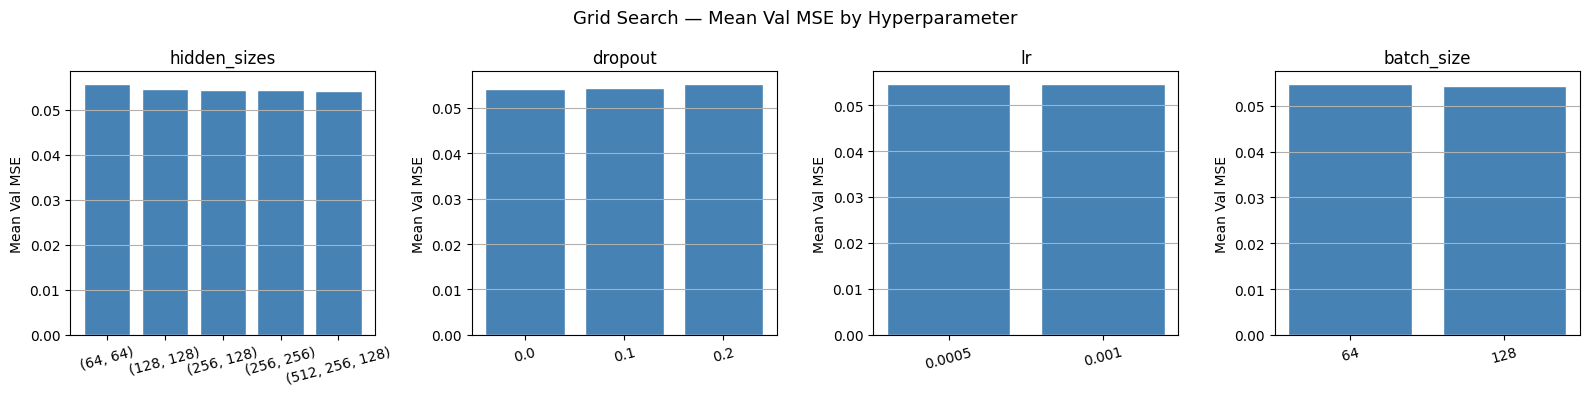

In [32]:
gs_df = pd.DataFrame(gs_results).sort_values("best_val_mse").reset_index(drop=True)
print("Top 10 configurations:")
print(gs_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key in zip(axes, ["hidden_sizes", "dropout", "lr", "batch_size"]):
    group  = gs_df.groupby(key)["best_val_mse"].mean().reset_index()
    labels = [str(v) for v in group[key]]
    ax.bar(labels, group["best_val_mse"], color="steelblue", edgecolor="white")
    ax.set_title(key); ax.set_ylabel("Mean Val MSE")
    ax.tick_params(axis="x", rotation=15); ax.grid(axis="y")
plt.suptitle("Grid Search — Mean Val MSE by Hyperparameter", fontsize=13)
plt.tight_layout(); plt.show()

## 9. Full Training of Best Configuration

In [33]:
print(f"Re-training best config: {best_gs_params}\n")

train_loader, val_loader, test_loader = make_loaders(best_gs_params["batch_size"])

model = PINNForwardNet(
    in_dim=len(INPUT_COLS), out_dim=len(OUTPUT_COLS),
    hidden_sizes=best_gs_params["hidden_sizes"],
    dropout=best_gs_params["dropout"]
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

train_losses, val_losses, best_val_loss = train_model(
    model, train_loader, val_loader,
    epochs=500, patience=30, lr=best_gs_params["lr"], verbose=True
)
print(f"\nFinal best validation loss: {best_val_loss:.5f}")

Re-training best config: {'hidden_sizes': (128, 128), 'dropout': 0.0, 'lr': 0.001, 'batch_size': 128}

Model parameters: 18,307
PINNForwardNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)
  Epoch    1 | Train: 0.35378 | Val: 0.23031 | LR: 1.00e-03


C:\Users\tudor\AppData\Roaming\Python\Python313\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch   20 | Train: 0.07046 | Val: 0.05555 | LR: 1.00e-03
  Epoch   40 | Train: 0.06535 | Val: 0.05575 | LR: 5.00e-04
  Early stopping at epoch 53

Final best validation loss: 0.05368


## 10. Evaluate on Test Set

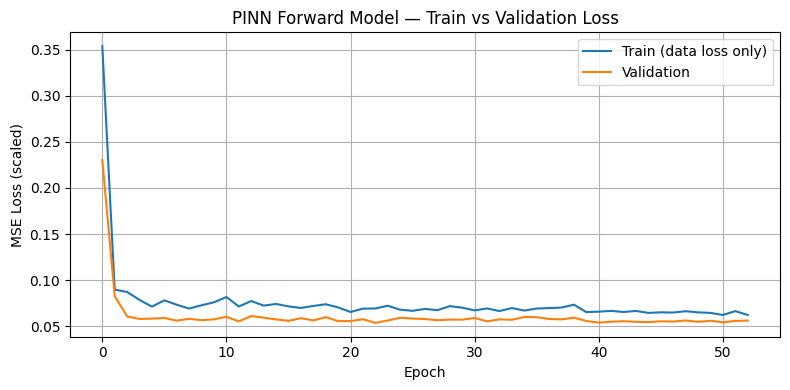

PINN Forward Model — Test Set Performance (physical units)
-----------------------------------------------------------------
  Sensor Displacement             MAE=0.0066   RMSE=0.0128   MAPE=8.46%
  Max Mechanical Stress           MAE=1.4334   RMSE=2.5858   MAPE=2.07%
  Vol                             MAE=2.4145   RMSE=2.9990   MAPE=0.39%


In [34]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train (data loss only)"); plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss (scaled)")
plt.title("PINN Forward Model — Train vs Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

model.eval()
preds_scaled, trues_scaled = [], []
with torch.no_grad():
    for xb, yb, _ in test_loader:
        preds_scaled.append(model(xb.to(device)).cpu())
        trues_scaled.append(yb)

preds_scaled = torch.cat(preds_scaled).numpy()
trues_scaled = torch.cat(trues_scaled).numpy()

preds_phys = scaler_y.inverse_transform(preds_scaled)
trues_phys = scaler_y.inverse_transform(trues_scaled)

mae_arr  = np.mean(np.abs(preds_phys - trues_phys), axis=0)
rmse_arr = np.sqrt(np.mean((preds_phys - trues_phys) ** 2, axis=0))
mape_arr = np.mean(np.abs((preds_phys - trues_phys) / trues_phys) * 100, axis=0)

print("PINN Forward Model — Test Set Performance (physical units)")
print("-" * 65)
for i, col in enumerate(OUTPUT_COLS):
    print(f"  {col:<30s}  MAE={mae_arr[i]:.4f}   RMSE={rmse_arr[i]:.4f}   MAPE={mape_arr[i]:.2f}%")

## 11. Parity Plots

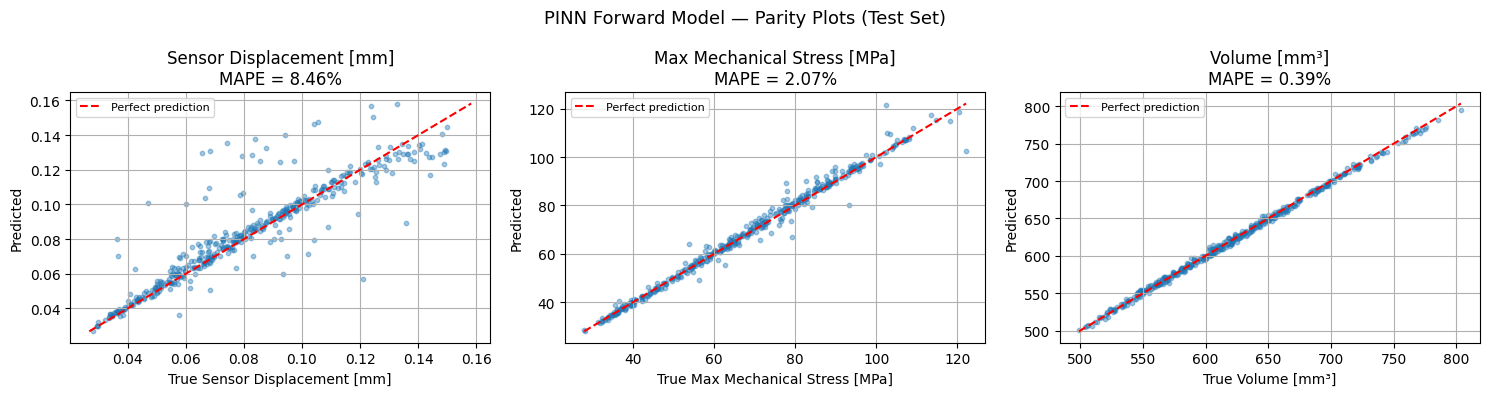

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["Sensor Displacement [mm]", "Max Mechanical Stress [MPa]", "Volume [mm³]"]

for i, ax in enumerate(axes):
    ax.scatter(trues_phys[:, i], preds_phys[:, i], alpha=0.4, s=10)
    lims = [min(trues_phys[:, i].min(), preds_phys[:, i].min()),
            max(trues_phys[:, i].max(), preds_phys[:, i].max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel(f"True {labels[i]}"); ax.set_ylabel("Predicted")
    ax.set_title(f"{labels[i]}\nMAPE = {mape_arr[i]:.2f}%")
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle("PINN Forward Model — Parity Plots (Test Set)", fontsize=13)
plt.tight_layout(); plt.show()

## 12. Save Model

Saves `pinn_forward_model.pt` and `pinn_scalers.pkl` to `../Models/`.

In [36]:
import joblib

MODEL_DIR = "../Models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path  = os.path.join(MODEL_DIR, "pinn_filter_forward_model.pt")
scaler_path = os.path.join(MODEL_DIR, "pinn_filter_scalers.pkl")

torch.save({
    "model_state_dict": model.state_dict(),
    "best_params"     : best_gs_params,
    "input_cols"      : INPUT_COLS,
    "output_cols"     : OUTPUT_COLS,
    "stress_factor"   : STRESS_FACTOR,
    "lambda_physics"  : LAMBDA_PHYSICS,
    "test_indices"    : test_indices.tolist(),
}, model_path)

joblib.dump({"scaler_x": scaler_x, "scaler_y": scaler_y}, scaler_path)

print(f"Model saved to  : {model_path}")
print(f"Scalers saved to: {scaler_path}")

Model saved to  : ../Models\pinn_filter_forward_model.pt
Scalers saved to: ../Models\pinn_filter_scalers.pkl
